## Requirements to run this notebook standalone

Run **Task02_03_Data_Understanding_Preprocessing.ipynb** first (or place its output files `X_train.csv`, `X_test.csv`, `X_train_scaled.csv`, `X_test_scaled.csv`, `y_train.csv`, `y_test.csv` in the same folder as this notebook).

This notebook covers **Task 05 (Machine Learning Model Development)**. It requires `xgboost` to be installed (`pip install xgboost`).

# Task 05 — Machine Learning Model Development

In this part of the notebook we train **all seven** models listed below for a more thorough comparison:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Support Vector Machine (SVM)
5. Naïve Bayes
6. K-Nearest Neighbors (KNN)
7. XGBoost

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 5.1. Importing Required Libraries

In [2]:
import time
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)

RANDOM_STATE = 42

## 5.2. Load Preprocessed Data From Task 3

We use the **unscaled** feature set for tree-based / probability-based models (Decision Tree, Random Forest,
Naïve Bayes, XGBoost), which do not require scaling.
The **scaled** feature set for models sensitive to feature magnitude (Logistic Regression, SVM, KNN).

In [3]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
X_train_scaled = pd.read_csv('../data/processed/X_train_scaled.csv')
X_test_scaled = pd.read_csv('../data/processed/X_test_scaled.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Train class balance:\n', y_train.value_counts(normalize=True).round(3))
print('Test class balance:\n', y_test.value_counts(normalize=True).round(3))

Train: (800, 61)  Test: (200, 61)
Train class balance:
 readmitted_30_days
0    0.748
1    0.252
Name: proportion, dtype: float64
Test class balance:
 readmitted_30_days
0    0.745
1    0.255
Name: proportion, dtype: float64


**Class imbalance handling:** The target is imbalanced ( Approximately 74.7% / 25.3%). Where the algorithm supports it,
we use **"class_weight='balanced'"** so the model penalises mistakes on the minority which is the **"readmitted_30_days"** class more heavily.

XGBoost uses the equivalent **"scale_pos_weight"**.

Naïve Bayes and KNN do not have a native class-weighting mechanism, so we evaluate them as it is and rely on **threshold-independent metrics (ROC-AUC)** plus precision/recall/F1 in Task 06 to give a fair, imbalance aware comparison rather than accuracy alone.

In [4]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print('scale_pos_weight for XGBoost:', round(scale_pos_weight, 3))

scale_pos_weight for XGBoost: 2.96


## 5.3. Model Definitions and Hyperparameter Grids

Each model is paired with a small, sensible hyperparameter grid. Given the dataset size (~800 training rows),
**"GridSearchCV"** with 5-fold cross-validation is computationally feasible and gives an exhaustive search over
each grid (rather than a random subset), which is preferable at this scale.

In [5]:
model_configs = {
    'Logistic Regression': {
        'estimator': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
        'params': {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'], 'solver': ['lbfgs']},
        'data': 'scaled'
    },
    'Decision Tree': {
        'estimator': DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
        'params': {'max_depth': [3, 5, 7, 10, None], 'min_samples_leaf': [1, 5, 10],
                   'criterion': ['gini', 'entropy']},
        'data': 'raw'
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
        'params': {'n_estimators': [100, 200], 'max_depth': [5, 10, None],
                   'min_samples_leaf': [1, 5]},
        'data': 'raw'
    },
    'SVM': {
        'estimator': SVC(probability=True, class_weight='balanced', random_state=RANDOM_STATE),
        'params': {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear']},
        'data': 'scaled'
    },
    'Naive Bayes': {
        'estimator': GaussianNB(),
        'params': {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]},
        'data': 'scaled'
    },
    'KNN': {
        'estimator': KNeighborsClassifier(),
        'params': {'n_neighbors': [3, 5, 7, 9, 11, 15], 'weights': ['uniform', 'distance']},
        'data': 'scaled'
    },
    'XGBoost': {
        'estimator': XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss',
                                    random_state=RANDOM_STATE),
        'params': {'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.2]},
        'data': 'raw'
    },
}
print("Models configured:\n")

for model_name in model_configs:
    print("✓", model_name)

Models configured:

✓ Logistic Regression
✓ Decision Tree
✓ Random Forest
✓ SVM
✓ Naive Bayes
✓ KNN
✓ XGBoost


## 5.4. Model Training with Hyperparameter Selection (GridSearchCV)

For each model we run a grid search (5-fold CV, scoring = ROC-AUC), fit the best estimator on the full
training set, and store it for evaluation.

In [6]:
fitted_models = {}
best_params_summary = {}
train_times = {}
best_cv_roc_auc_scores = {}

for name, cfg in model_configs.items():
    Xtr = X_train_scaled if cfg['data'] == 'scaled' else X_train
    t0 = time.time()
    grid = GridSearchCV(cfg['estimator'], cfg['params'], cv=5, scoring='roc_auc', n_jobs=-1)
    grid.fit(Xtr, y_train)
    elapsed = time.time() - t0

    fitted_models[name] = grid.best_estimator_
    best_params_summary[name] = grid.best_params_
    train_times[name] = elapsed
    best_cv_roc_auc_scores[name] = grid.best_score_

    print(f'{name:20s} | best CV ROC-AUC = {grid.best_score_:.4f} | time = {elapsed:.1f}s')
    print(f'{""*20} | best params: {grid.best_params_}')

c:\Projects\SmartCare-Readmission-Prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Logistic Regression  | best CV ROC-AUC = 0.9715 | time = 6.8s
 | best params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Decision Tree        | best CV ROC-AUC = 0.9651 | time = 0.8s
 | best params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 10}
Random Forest        | best CV ROC-AUC = 0.9649 | time = 4.1s
 | best params: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 100}


c:\Projects\SmartCare-Readmission-Prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM                  | best CV ROC-AUC = 0.9684 | time = 1.0s
 | best params: {'C': 10, 'kernel': 'rbf'}
Naive Bayes          | best CV ROC-AUC = 0.9554 | time = 0.1s
 | best params: {'var_smoothing': 1e-09}
KNN                  | best CV ROC-AUC = 0.9644 | time = 0.6s
 | best params: {'n_neighbors': 15, 'weights': 'distance'}
XGBoost              | best CV ROC-AUC = 0.9674 | time = 4.3s
 | best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


## 5.5. Hyperparameter Selection Summery

In [7]:
params_df = pd.DataFrame([
    {'Model': name, 'Best Hyperparameters': str(params), 'Training Time (s)': round(train_times[name], 1)}
    for name, params in best_params_summary.items()
])
params_df

,Model,Best Hyperparameters,Training Time (s)
0,Logistic Regression,"{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}",6.8
1,Decision Tree,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.8
2,Random Forest,"{'max_depth': None, 'min_samples_leaf': 5, 'n_...",4.1
3,SVM,"{'C': 10, 'kernel': 'rbf'}",1.0
4,Naive Bayes,{'var_smoothing': 1e-09},0.1
5,KNN,"{'n_neighbors': 15, 'weights': 'distance'}",0.6
6,XGBoost,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",4.3


## 5.6. Model Evaluation on the Test Set

We compute Accuracy, Precision, Recall, F1 Score, and ROC-AUC for every model on the held-out test set. Full
evaluation (confusion matrices, ROC curves, best-model justification) continues in Task 06, here we compute
the metrics needed for the comparative analysis this task requires.

In [8]:
results = []
roc_data = {}

for name, model in fitted_models.items():
    cfg = model_configs[name]
    Xte = X_test_scaled if cfg['data'] == 'scaled' else X_test

    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    })
    roc_data[name] = roc_curve(y_test, y_proba)

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.895,0.7083,1.0000,0.8293,0.9578
1,Logistic Regression,0.885,0.7000,0.9608,0.8099,0.9485
2,SVM,0.880,0.7077,0.9020,0.7931,0.9484
3,XGBoost,0.895,0.7083,1.0000,0.8293,0.9405
4,KNN,0.860,0.7170,0.7451,0.7308,0.9355
5,Naive Bayes,0.895,0.7083,1.0000,0.8293,0.9342
6,Decision Tree,0.895,0.7083,1.0000,0.8293,0.9230


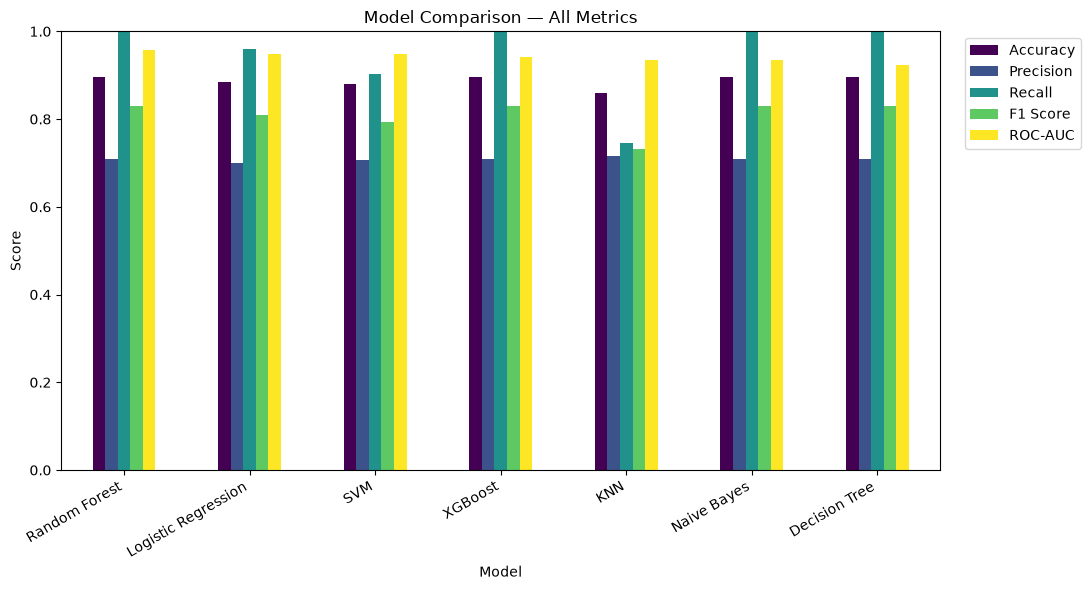

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))
plot_df = results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']]
plot_df.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title('Model Comparison — All Metrics')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../outputs/model_comparison_bar.png', dpi=110, bbox_inches='tight')
plt.show()

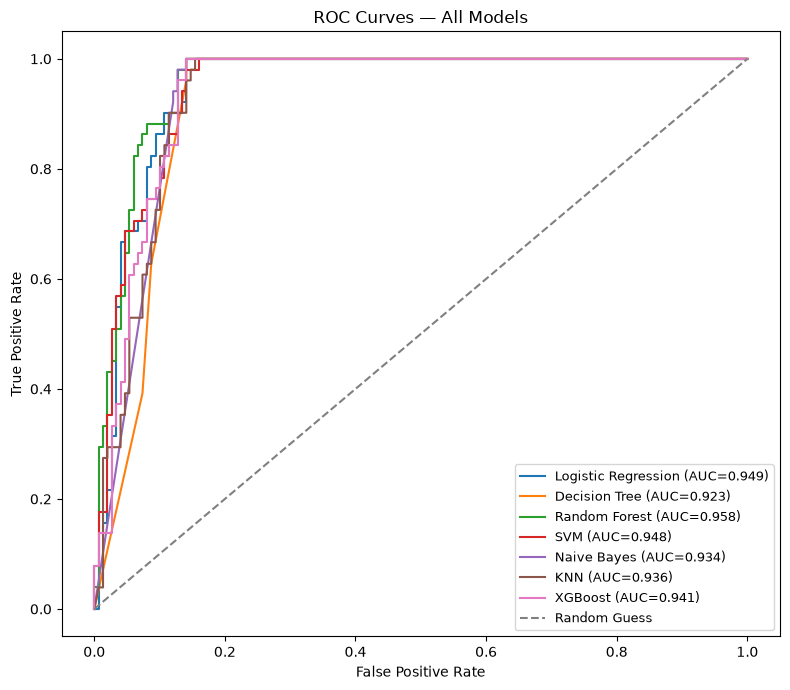

In [10]:
plt.figure(figsize=(8, 7))
for name, (fpr, tpr, _) in roc_data.items():
    auc = results_df.set_index('Model').loc[name, 'ROC-AUC']
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/roc_curves_all_models.png', dpi=110, bbox_inches='tight')
plt.show()

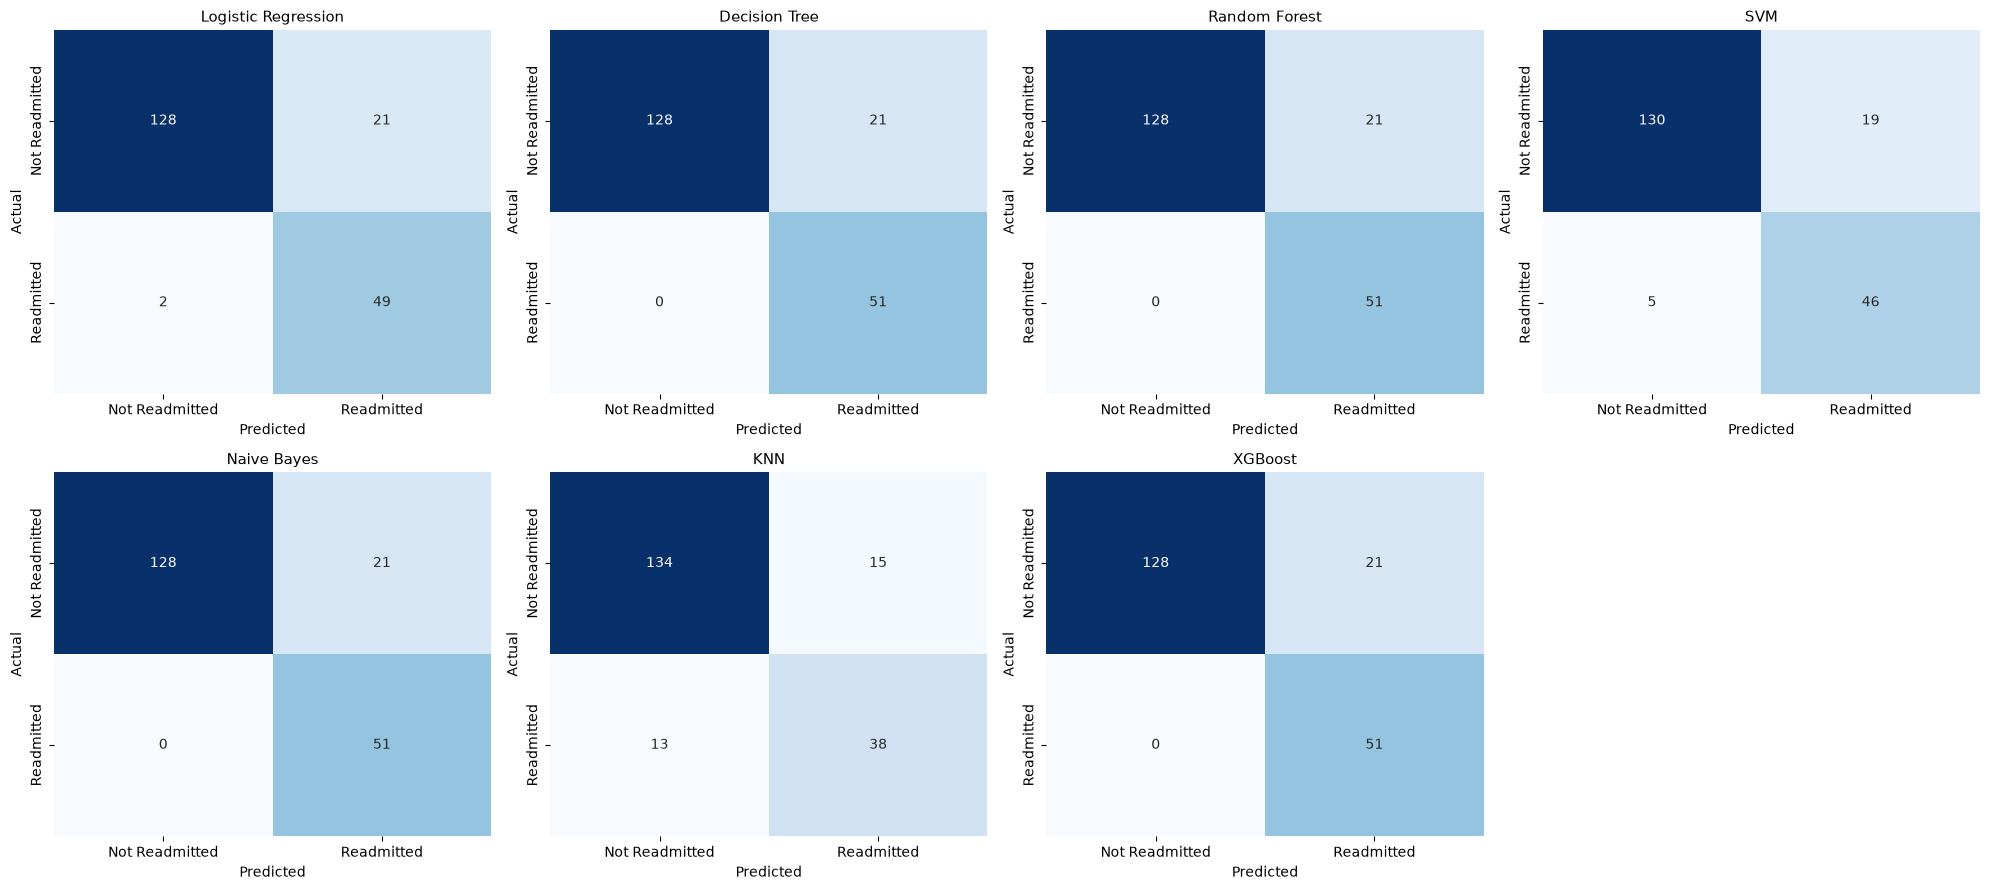

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for i, (name, model) in enumerate(fitted_models.items()):
    cfg = model_configs[name]
    Xte = X_test_scaled if cfg['data'] == 'scaled' else X_test
    y_pred = model.predict(Xte)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Not Readmitted', 'Readmitted'],
                yticklabels=['Not Readmitted', 'Readmitted'])
    axes[i].set_title(name, fontsize=11)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
for j in range(len(fitted_models), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig('../outputs/confusion_matrices_all_models.png', dpi=110, bbox_inches='tight')
plt.show()

## 5.7. **Comparative discussion:**

- **Tree-based ensemble models (Random Forest, XGBoost)** are expected to perform strongly, as they can
  capture the non-linear, multi-feature interactions identified in the Task 04 EDA (e.g. utilisation-history
  features combining to drive risk), and both natively support class-imbalance handling.

- **Logistic Regression** provides an interpretable linear baseline; if it performs close to the ensemble
  models, it suggests the decision boundary is close to linear in the engineered feature space.

- **SVM** with an RBF kernel can capture non-linear boundaries but is more sensitive to hyperparameter choice
  and scaling; its **"class_weight='balanced' "** setting compensates for the imbalance.

- **Naïve Bayes** assumes feature independence, which is unlikely to hold fully here (e.g.
  **"total_prior_visits"** overlaps with **"previous_admissions"**), so it is included as a fast, simple baseline
  rather than an expected top performer.

- **KNN** has no explicit imbalance handling and can be sensitive to the curse of dimensionality after
  one-hot encoding (Task 03 produced many binary columns); its relative ranking here is informative of how
  much that hurts performance on this dataset.

The full ranked comparison table (Section 5) and the ROC curves above give the quantitative basis for
selecting the best-performing model, which is finalised with deeper metric analysis in **Task 06 (Model
Evaluation)**.

## 5.8. Save Trained Models and Results

All 7 fitted models, their metadata (which feature set they use), and the comparison table are saved for reuse
in Task 06 (Model Evaluation) and Task 07 (Explainable AI).

In [12]:
joblib.dump(fitted_models, '../models/trained_models.pkl')

joblib.dump(fitted_models['Logistic Regression'], '../models/logistic_regression_model.pkl')

model_data_map = {name: cfg['data'] for name, cfg in model_configs.items()}
joblib.dump(model_data_map, '../models/model_data_map.pkl')

results_df.to_csv('../data/processed/model_comparison_results.csv', index=False)
params_df.to_csv('../data/processed/model_hyperparameters.csv', index=False)

print('Saved: trained_models.pkl, model_data_map.pkl, model_comparison_results.csv, model_hyperparameters.csv')

Saved: trained_models.pkl, model_data_map.pkl, model_comparison_results.csv, model_hyperparameters.csv


## 5.9. Summary

- **7 models trained**: Logistic Regression, Decision Tree, Random Forest, SVM, Naïve Bayes, KNN, XGBoost —
  exceeding the minimum requirement of 3.

- **Hyperparameters selected via **"GridSearchCV`** (5-fold CV, ROC-AUC scoring) for every model.

- **Comparative analysis** performed via a metrics table, grouped bar chart, ROC curve overlay, and
  side-by-side confusion matrices.

- Class imbalance was addressed through **"class_weight='balanced' "** / **"scale_pos_weight"** where supported, and by
  prioritising ROC-AUC/F1 over raw accuracy throughout.

- All trained models and results are serialized for the deeper evaluation in Task 06 and the explainability
  analysis in Task 07.

## 5.10. BONUS — Deep Learning Model (MLP)

This section trains a small feed-forward neural network (Multi-Layer Perceptron) using TensorFlow/Keras on the same scaled features used for Logistic Regression / SVM / KNN, and evaluates it with the exact same metrics as the other 7 models so it can be compared directly on the leaderboard above.

Requires **"tensorflow"** to be installed: **"pip install tensorflow"**.

### 5.10.1.Imports and Reproduccibility

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


### 5.10.2. Build the MLP Architecture

A small, regularised network is appropriate given the dataset size (~800 training rows): two hidden layers with dropout to reduce overfitting, and a single sigmoid output neuron for binary classification (matching the other 7 models' target of **"readmitted_30_days"**).

In [14]:
n_features = X_train_scaled.shape[1]

mlp_model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

mlp_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc'), 'accuracy']
)

mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,081 (23.75 KB)

 Trainable params: 6,081 (23.75 KB)

 Non-trainable params: 0 (0.00 B)

### 5.10.3. Class Imbalance Handling and Training

The same imbalance handling philosophy used for the sklearn models (**"class_weight='balanced'"**) is applied here via Keras's **"class_weight"** argument, so the minority (**"readmitted"**) class is penalised proportionally more during training. **"EarlyStopping"** on validation ROC-AUC prevents overfitting and removes the need to hand-pick a fixed number of epochs.

In [15]:
neg, pos = np.bincount(y_train)
total = neg + pos
class_weight = {0: total / (2 * neg), 1: total / (2 * pos)}
print('Class weights:', class_weight)

early_stop = callbacks.EarlyStopping(
    monitor='val_auc', mode='max', patience=15, restore_best_weights=True
)

t0 = time.time()
history = mlp_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)
mlp_train_time = time.time() - t0
print(f'\nMLP training time: {mlp_train_time:.1f}s, stopped at epoch {len(history.history["loss"])}')

Class weights: {0: np.float64(0.6688963210702341), 1: np.float64(1.9801980198019802)}
Epoch 1/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.6781 - auc: 0.6286 - loss: 0.6625 - val_accuracy: 0.8313 - val_auc: 0.8828 - val_loss: 0.5910
Epoch 2/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7719 - auc: 0.8173 - loss: 0.5671 - val_accuracy: 0.8813 - val_auc: 0.9497 - val_loss: 0.4981
Epoch 3/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8766 - auc: 0.9358 - loss: 0.4392 - val_accuracy: 0.9250 - val_auc: 0.9572 - val_loss: 0.3743
Epoch 4/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8969 - auc: 0.9510 - loss: 0.3315 - val_accuracy: 0.9187 - val_auc: 0.9593 - val_loss: 0.2868
Epoch 5/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9203 - auc: 0.9637 - loss: 0.2429 - val_accuracy: 0.9250 - val_auc: 0.9608 - val_loss: 0.2499
Epoch 6/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9312 - auc: 0.9687 - loss: 0.1977 - val_accuracy: 0.

### 5.10.4. Training Curves

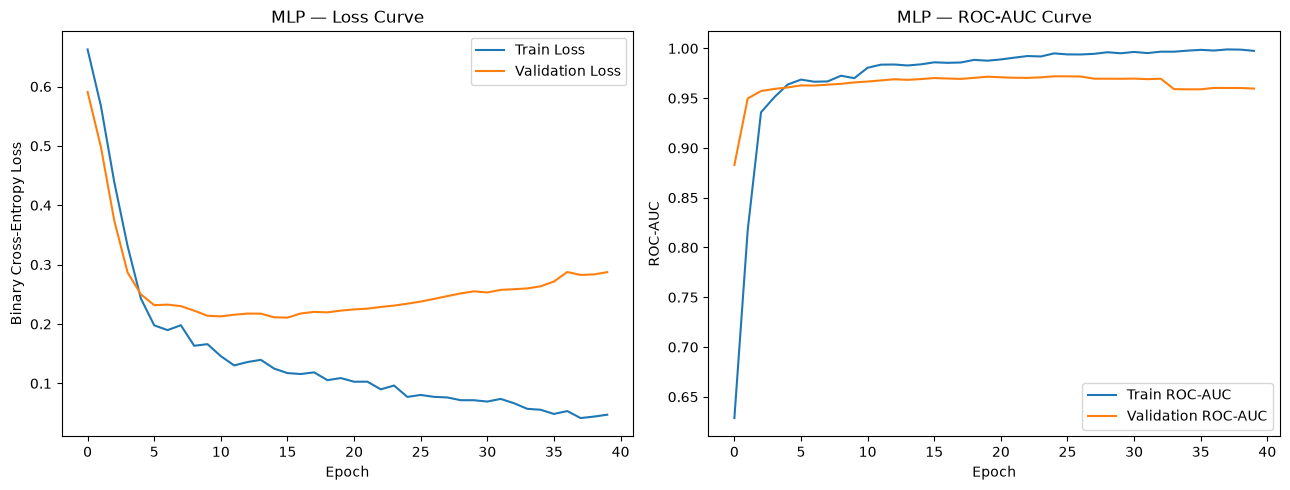

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('MLP — Loss Curve')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].legend()

axes[1].plot(history.history['auc'], label='Train ROC-AUC')
axes[1].plot(history.history['val_auc'], label='Validation ROC-AUC')
axes[1].set_title('MLP — ROC-AUC Curve')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('ROC-AUC')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/mlp_training_curves.png', dpi=110, bbox_inches='tight')
plt.show()

### 5.10.5. Evaluate on the Test Set

Computed with the same five metrics as the other 7 models and appended to **"results_df"** so it appears directly in the comparison table and ROC plot below.

In [17]:
y_proba_mlp = mlp_model.predict(X_test_scaled).ravel()
y_pred_mlp = (y_proba_mlp >= 0.5).astype(int)

mlp_result_row = {
    'Model': 'Deep Learning (MLP)',
    'Accuracy': accuracy_score(y_test, y_pred_mlp),
    'Precision': precision_score(y_test, y_pred_mlp),
    'Recall': recall_score(y_test, y_pred_mlp),
    'F1 Score': f1_score(y_test, y_pred_mlp),
    'ROC-AUC': roc_auc_score(y_test, y_proba_mlp),
}

results_df = pd.concat([results_df, pd.DataFrame([mlp_result_row])], ignore_index=True)
results_df = results_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
roc_data['Deep Learning (MLP)'] = roc_curve(y_test, y_proba_mlp)

print('Updated leaderboard (now 8 models):')
results_df.round(4)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Updated leaderboard (now 8 models):


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.895,0.7083,1.0000,0.8293,0.9578
1,Logistic Regression,0.885,0.7000,0.9608,0.8099,0.9485
2,SVM,0.880,0.7077,0.9020,0.7931,0.9484
3,Deep Learning (MLP),0.895,0.7206,0.9608,0.8235,0.9442
4,XGBoost,0.895,0.7083,1.0000,0.8293,0.9405
5,KNN,0.860,0.7170,0.7451,0.7308,0.9355
6,Naive Bayes,0.895,0.7083,1.0000,0.8293,0.9342
7,Decision Tree,0.895,0.7083,1.0000,0.8293,0.9230


### 5.10.6. Updated Comparison Chart (All 8 Models)

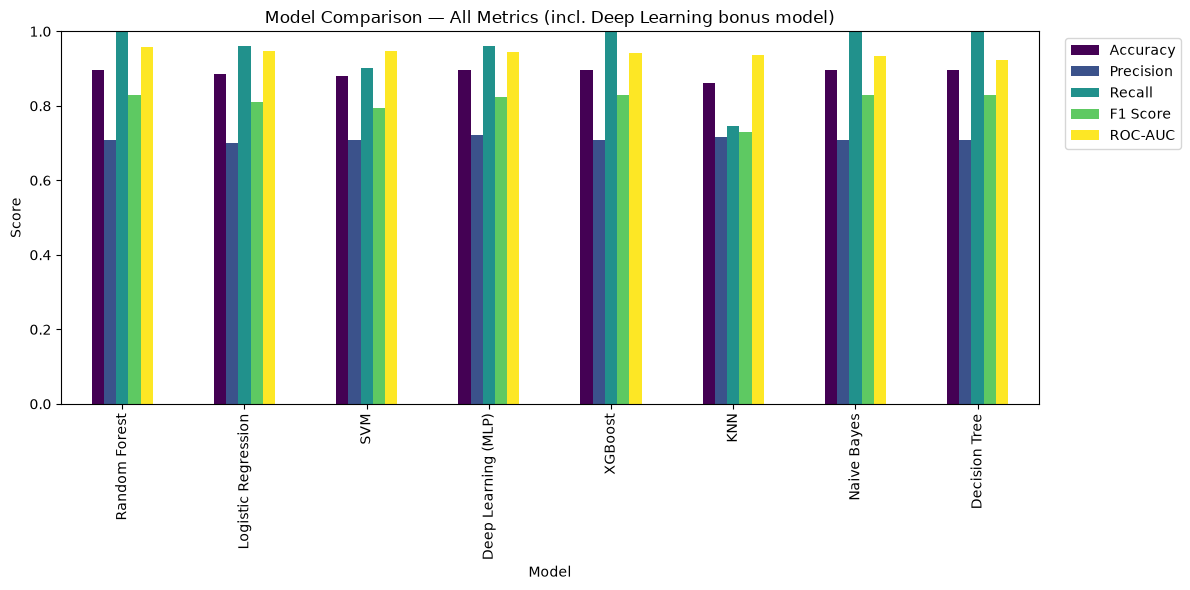

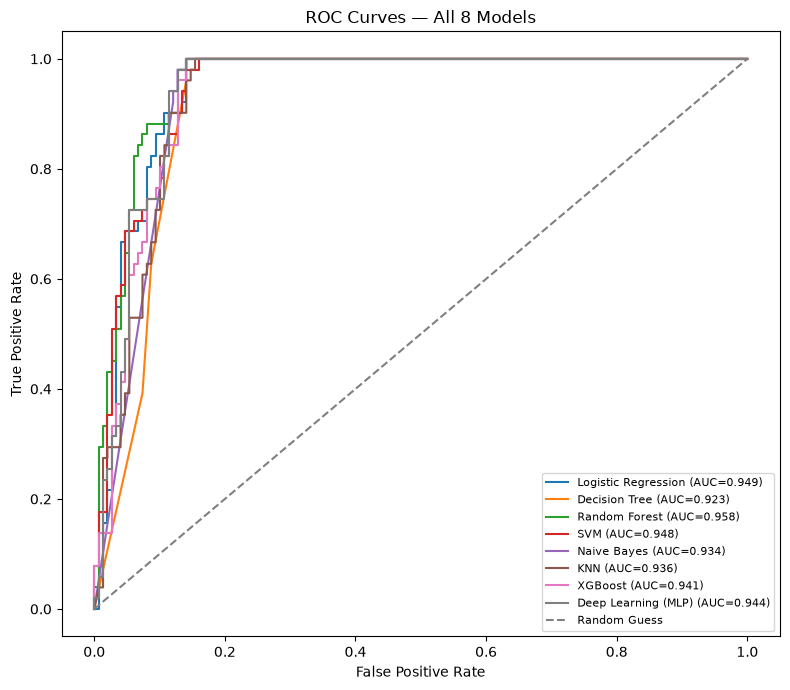

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_df = results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']]
plot_df.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title('Model Comparison — All Metrics (incl. Deep Learning bonus model)')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../outputs/model_comparison_with_mlp.png', dpi=110, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 7))
for name, (fpr, tpr, _) in roc_data.items():
    auc_val = results_df.set_index('Model').loc[name, 'ROC-AUC']
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random Guess')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All 8 Models')
plt.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/roc_curves_with_mlp.png', dpi=110, bbox_inches='tight')
plt.show()

### 5.10.7. Save the MLP Model

Keras models are saved in the native **".keras"** format rather than via **"joblib"**, since TensorFlow models are not reliably compatible with **"joblib"**/**"pickle"** the way scikit-learn estimators are. This is saved as a **separate file** from **"trained_models.pkl"** so the existing Task 06/07 pipeline (which loads the 7 sklearn/XGBoost models) is unaffected. The MLP's test-set results are exported separately so they can be merged into the Task 06 comparison table manually if desired.

In [19]:
mlp_model.save('../models/mlp_model.keras')
pd.DataFrame([mlp_result_row]).to_csv('../data/processed/mlp_model_results.csv', index=False)

print('Saved: ../models/mlp_model.keras, ../data/processed/mlp_model_results.csv')
print('\nTo load it again later:')
print(">>> from tensorflow import keras")
print(">>> mlp_model = keras.models.load_model('../models/mlp_model.keras')")

Saved: ../models/mlp_model.keras, ../data/processed/mlp_model_results.csv

To load it again later:
>>> from tensorflow import keras
>>> mlp_model = keras.models.load_model('../models/mlp_model.keras')


## 5.11. Hyperparameter Optimization

### 5.11.1. Install and import

In [20]:
!pip install keras-tuner --quiet
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers, callbacks

### 5.11.2. Define a build function (this is Keras Tuner's version of a model factory)

In [21]:
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_scaled.shape[1],)))

    # Tune number of hidden layers
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(layers.Dense(
            units=hp.Int(f'units_{i}', min_value=16, max_value=128, step=16),
            activation='relu'
        ))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(
            hp.Float(f'dropout_{i}', min_value=0.1, max_value=0.5, step=0.1)
        ))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', [1e-2, 1e-3, 5e-4, 1e-4])
        ),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')]
    )
    return model

### 5.11.3. Set up the tuner

In [22]:
tuner = kt.BayesianOptimization(
    build_model,
    objective=kt.Objective('val_auc', direction='max'),
    max_trials=25,
    executions_per_trial=1,
    directory='ann_tuning',
    project_name='readmission_ann_tuning',
    overwrite=True
)

tuner.search_space_summary()

Search space summary
Default search space size: 4
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 128, 'step': 16, 'sampling': 'linear'}
dropout_0 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0005, 0.0001], 'ordered': True}


### 5.11.4. Run the search

In [23]:
# Work around a keras-tuner limitation: internally, every trial tries to import
# TensorBoard's hparams plugin (via _configure_tensorboard_dir), even though no
# TensorBoard callback was requested here. This crashes with
# 'ModuleNotFoundError: No module named tensorboard' on environments where
# tensorboard isn't installed (installing it also works, but this patch avoids
# the dependency entirely and is more reliable across machines/venvs).
from keras_tuner.src.engine import tuner as _kt_tuner_engine
_kt_tuner_engine.Tuner._configure_tensorboard_dir = lambda self, callbacks, trial, execution=0: None

In [24]:
neg, pos = np.bincount(y_train)
class_weight = {0: 1.0, 1: neg / pos}

early_stop = callbacks.EarlyStopping(
    monitor='val_auc', mode='max', patience=6, restore_best_weights=True
)

tuner.search(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

Trial 25 Complete [00h 00m 18s]
val_auc: 0.9731121063232422

Best val_auc So Far: 0.9775934219360352
Total elapsed time: 00h 06m 25s


### 5.11.5. Inspect the best hyperparameters found

In [25]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print('Best hyperparameters found:')
for param, value in best_hp.values.items():
    print(f'  {param}: {value}')

tuner.results_summary(num_trials=5)  # see top 5 trials for comparison

Best hyperparameters found:
  num_layers: 1
  units_0: 32
  dropout_0: 0.2
  learning_rate: 0.01
  units_1: 80
  dropout_1: 0.1
  units_2: 32
  dropout_2: 0.1
Results summary
Results in ann_tuning\readmission_ann_tuning
Showing 5 best trials
Objective(name="val_auc", direction="max")

Trial 22 summary
Hyperparameters:
num_layers: 1
units_0: 32
dropout_0: 0.2
learning_rate: 0.01
units_1: 80
dropout_1: 0.1
units_2: 32
dropout_2: 0.1
Score: 0.9775934219360352

Trial 21 summary
Hyperparameters:
num_layers: 2
units_0: 16
dropout_0: 0.1
learning_rate: 0.01
units_1: 112
dropout_1: 0.2
units_2: 80
dropout_2: 0.4
Score: 0.9764492511749268

Trial 15 summary
Hyperparameters:
num_layers: 2
units_0: 32
dropout_0: 0.2
learning_rate: 0.0005
units_1: 16
dropout_1: 0.4
units_2: 96
dropout_2: 0.4
Score: 0.9753051400184631

Trial 13 summary
Hyperparameters:
num_layers: 2
units_0: 48
dropout_0: 0.5
learning_rate: 0.01
units_1: 64
dropout_1: 0.4
units_2: 96
dropout_2: 0.2
Score: 0.9738749265670776

Trial 2

### 5.11.6. Build and retrain the best model on the full training set

In [26]:
best_ann_tuned = tuner.hypermodel.build(best_hp)

history_tuned = best_ann_tuned.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - auc: 0.9006 - loss: 0.6502 - val_auc: 0.9621 - val_loss: 0.2446
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - auc: 0.9748 - loss: 0.2789 - val_auc: 0.9662 - val_loss: 0.2096
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - auc: 0.9849 - loss: 0.2075 - val_auc: 0.9698 - val_loss: 0.2083
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - auc: 0.9913 - loss: 0.1674 - val_auc: 0.9692 - val_loss: 0.2139
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - auc: 0.9934 - loss: 0.1399 - val_auc: 0.9684 - val_loss: 0.2157
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - auc: 0.9961 - loss: 0.1167 - val_auc: 0.9677 - val_loss: 0.2096
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - auc: 0.9953 - loss: 0.1110 - val_auc: 0.9688 - val_loss: 0.2144
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - auc: 0.9980 - loss: 0.0900 - val_auc: 0.9688 - val_loss: 0.2253
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - auc: 0

### 5.11.7. Evaluate on the test set — same metrics as everything else

In [27]:
y_proba_tuned_ann = best_ann_tuned.predict(X_test_scaled).ravel()
y_pred_tuned_ann = (y_proba_tuned_ann >= 0.5).astype(int)

tuned_ann_row = {
    'Model': 'ANN (Keras Tuner-optimized)',
    'Accuracy': accuracy_score(y_test, y_pred_tuned_ann),
    'Precision': precision_score(y_test, y_pred_tuned_ann),
    'Recall': recall_score(y_test, y_pred_tuned_ann),
    'F1 Score': f1_score(y_test, y_pred_tuned_ann),
    'ROC-AUC': roc_auc_score(y_test, y_proba_tuned_ann),
}
print(tuned_ann_row)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
{'Model': 'ANN (Keras Tuner-optimized)', 'Accuracy': 0.85, 'Precision': 0.6909090909090909, 'Recall': 0.7450980392156863, 'F1 Score': 0.7169811320754716, 'ROC-AUC': 0.939070930385577}


### 5.11.8. Directly compare untuned vs tuned ANN

In [28]:
comparison = pd.DataFrame([mlp_result_row, tuned_ann_row]) 
comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Deep Learning (MLP),0.895,0.7206,0.9608,0.8235,0.9442
1,ANN (Keras Tuner-optimized),0.850,0.6909,0.7451,0.7170,0.9391


### 5.11.9. Plot training curves for the tuned model

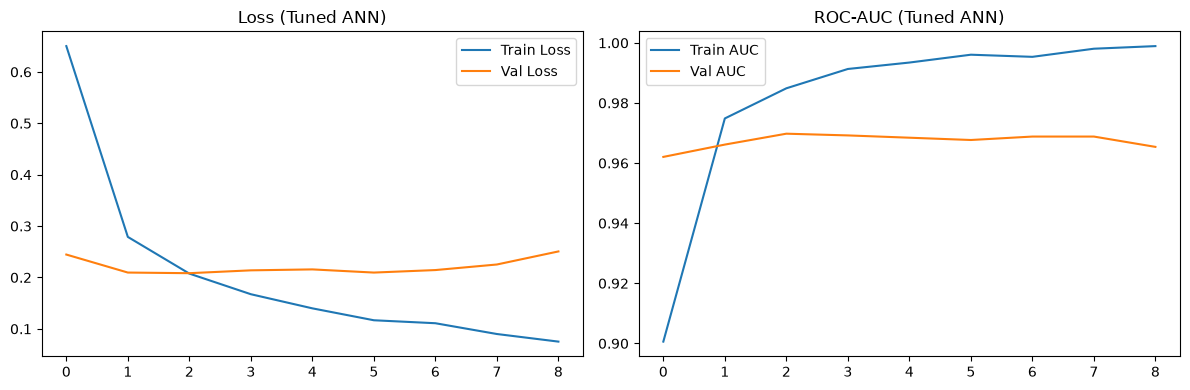

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_tuned.history['loss'], label='Train Loss')
axes[0].plot(history_tuned.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss (Tuned ANN)'); axes[0].legend()

axes[1].plot(history_tuned.history['auc'], label='Train AUC')
axes[1].plot(history_tuned.history['val_auc'], label='Val AUC')
axes[1].set_title('ROC-AUC (Tuned ANN)'); axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/tuned_ann_training_curves.png', dpi=110, bbox_inches='tight')
plt.show()

## 5.12. Ensemble Learning

### 5.12.1. Import

In [30]:
from sklearn.ensemble import VotingClassifier, StackingClassifier

### 5.12.2. Voting Classifier (soft voting)

In [31]:
voting_clf = VotingClassifier(
    estimators=[
        ('rf', fitted_models['Random Forest']),
        ('xgb', fitted_models['XGBoost']),
        ('dt', fitted_models['Decision Tree'])
    ],
    voting='soft'
)
voting_clf.fit(X_train, y_train)

y_pred_vote = voting_clf.predict(X_test)
y_proba_vote = voting_clf.predict_proba(X_test)[:, 1]

voting_row = {
    'Model': 'Voting Ensemble (RF+XGB+DT)',
    'Accuracy': accuracy_score(y_test, y_pred_vote),
    'Precision': precision_score(y_test, y_pred_vote),
    'Recall': recall_score(y_test, y_pred_vote),
    'F1 Score': f1_score(y_test, y_pred_vote),
    'ROC-AUC': roc_auc_score(y_test, y_proba_vote),
}
print(voting_row)

{'Model': 'Voting Ensemble (RF+XGB+DT)', 'Accuracy': 0.895, 'Precision': 0.7083333333333334, 'Recall': 1.0, 'F1 Score': 0.8292682926829268, 'ROC-AUC': 0.9415712593762338}


### 5.12.3. Stacking Classifier (meta-learner)

In [32]:
stack_clf = StackingClassifier(
    estimators=[
        ('rf', fitted_models['Random Forest']),
        ('xgb', fitted_models['XGBoost']),
        ('dt', fitted_models['Decision Tree'])
    ],
    final_estimator=LogisticRegression(max_iter=1000, class_weight='balanced'),
    cv=5,
    stack_method='predict_proba'
)
stack_clf.fit(X_train, y_train)

y_pred_stack = stack_clf.predict(X_test)
y_proba_stack = stack_clf.predict_proba(X_test)[:, 1]

stacking_row = {
    'Model': 'Stacking Ensemble (RF+XGB+DT → LR)',
    'Accuracy': accuracy_score(y_test, y_pred_stack),
    'Precision': precision_score(y_test, y_pred_stack),
    'Recall': recall_score(y_test, y_pred_stack),
    'F1 Score': f1_score(y_test, y_pred_stack),
    'ROC-AUC': roc_auc_score(y_test, y_proba_stack),
}
print(stacking_row)

{'Model': 'Stacking Ensemble (RF+XGB+DT → LR)', 'Accuracy': 0.895, 'Precision': 0.7083333333333334, 'Recall': 1.0, 'F1 Score': 0.8292682926829268, 'ROC-AUC': 0.9419660481642321}


### 5.12.4. Compare both ensembles against the individual base models

In [33]:
ensemble_comparison = pd.DataFrame([
    {'Model': 'Random Forest', 'ROC-AUC': results_df.set_index('Model').loc['Random Forest', 'ROC-AUC']},
    {'Model': 'XGBoost', 'ROC-AUC': results_df.set_index('Model').loc['XGBoost', 'ROC-AUC']},
    {'Model': 'Decision Tree', 'ROC-AUC': results_df.set_index('Model').loc['Decision Tree', 'ROC-AUC']},
    voting_row,
    stacking_row,
])[['Model', 'ROC-AUC']].sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

ensemble_comparison.round(4)

,Model,ROC-AUC
0,Random Forest,0.9578
1,Stacking Ensemble (RF+XGB+DT → LR),0.9420
2,Voting Ensemble (RF+XGB+DT),0.9416
3,XGBoost,0.9405
4,Decision Tree,0.9230


### 5.12.5. Confusion matrices side-by-side

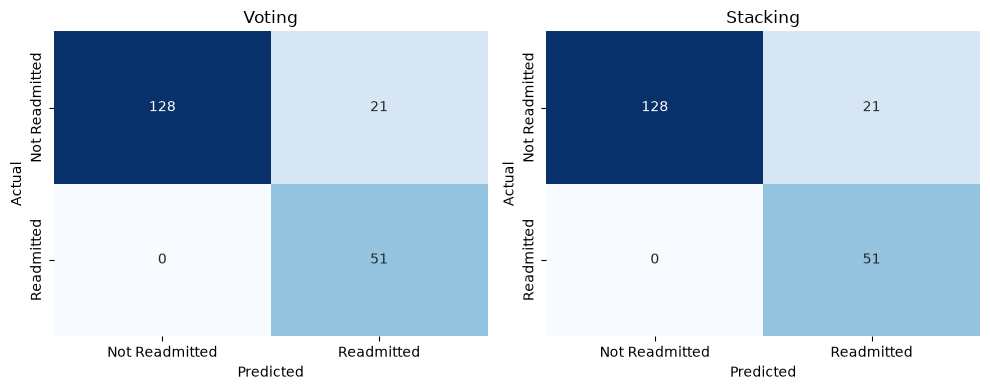

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, y_pred) in zip(axes, [('Voting', y_pred_vote), ('Stacking', y_pred_stack)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Not Readmitted', 'Readmitted'],
                yticklabels=['Not Readmitted', 'Readmitted'])
    ax.set_title(name)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('../outputs/ensemble_confusion_matrices.png', dpi=110, bbox_inches='tight')
plt.show()

### 5.12.6. Cross-validation stability check

In [35]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

vote_cv = cross_val_score(voting_clf, X_train, y_train, cv=cv, scoring='roc_auc')
stack_cv = cross_val_score(stack_clf, X_train, y_train, cv=cv, scoring='roc_auc')

print(f'Voting CV ROC-AUC: {vote_cv.mean():.4f} ± {vote_cv.std():.4f}')
print(f'Stacking CV ROC-AUC: {stack_cv.mean():.4f} ± {stack_cv.std():.4f}')

Voting CV ROC-AUC: 0.9669 ± 0.0155
Stacking CV ROC-AUC: 0.9668 ± 0.0156


### 5.12.7. Save Ensemble for Task 06

In [36]:
fitted_models['Voting Ensemble (RF+XGB+DT)'] = voting_clf
fitted_models['Stacking Ensemble (RF+XGB+DT -> LR)'] = stack_clf
model_data_map['Voting Ensemble (RF+XGB+DT)'] = 'raw'
model_data_map['Stacking Ensemble (RF+XGB+DT -> LR)'] = 'raw'

joblib.dump(fitted_models, '../models/trained_models.pkl')
joblib.dump(model_data_map, '../models/model_data_map.pkl')

print('Updated ../models/trained_models.pkl — now contains', len(fitted_models), 'models:')
for name in fitted_models:
    print(' -', name)

Updated ../models/trained_models.pkl — now contains 9 models:
 - Logistic Regression
 - Decision Tree
 - Random Forest
 - SVM
 - Naive Bayes
 - KNN
 - XGBoost
 - Voting Ensemble (RF+XGB+DT)
 - Stacking Ensemble (RF+XGB+DT -> LR)
